In [ ]:
#!pip install opencv-python numpy matplotlib (run this once only then comment out again) 

In [1]:
# Import necessary libraries for Milestone 2
import os
import cv2 # Make sure to run 'pip install opencv-python' in your terminal 
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# Define the path to your dataset
dataset_path = "Dataset"

image_paths = []
labels = []

# Loop through every folder and file
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    
    # Ensure it's a directory
    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            if image_name.endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, image_name))
                labels.append(folder_name) # The folder name is the label!

print(f"Total images found: {len(image_paths)}")
print(f"Classes found: {list(set(labels))}")

Total images found: 594
Classes found: ['rust', 'mildew', 'leaf_spot', 'healthy']


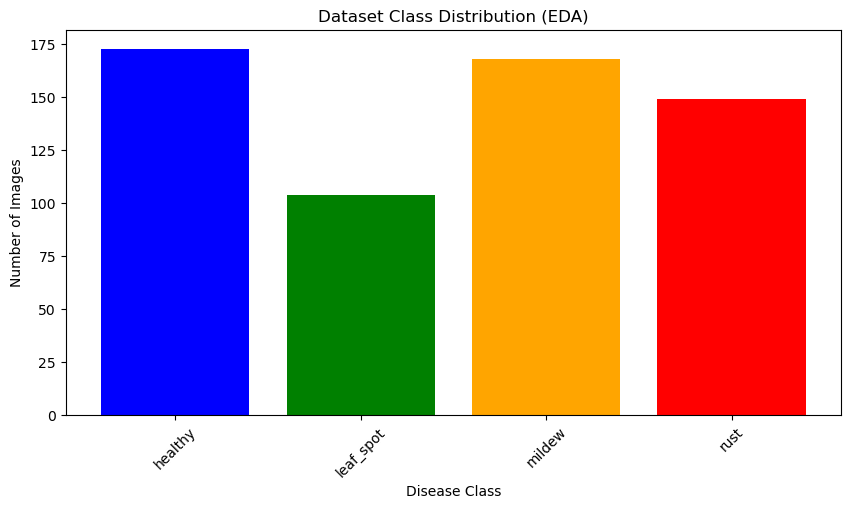

In [3]:
# Count how many images are in each class
class_counts = Counter(labels)

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'green', 'orange', 'red', 'purple'])
plt.title("Dataset Class Distribution (EDA)")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

# NOTE FOR REPORT: Use this chart to prove your dataset is balanced!

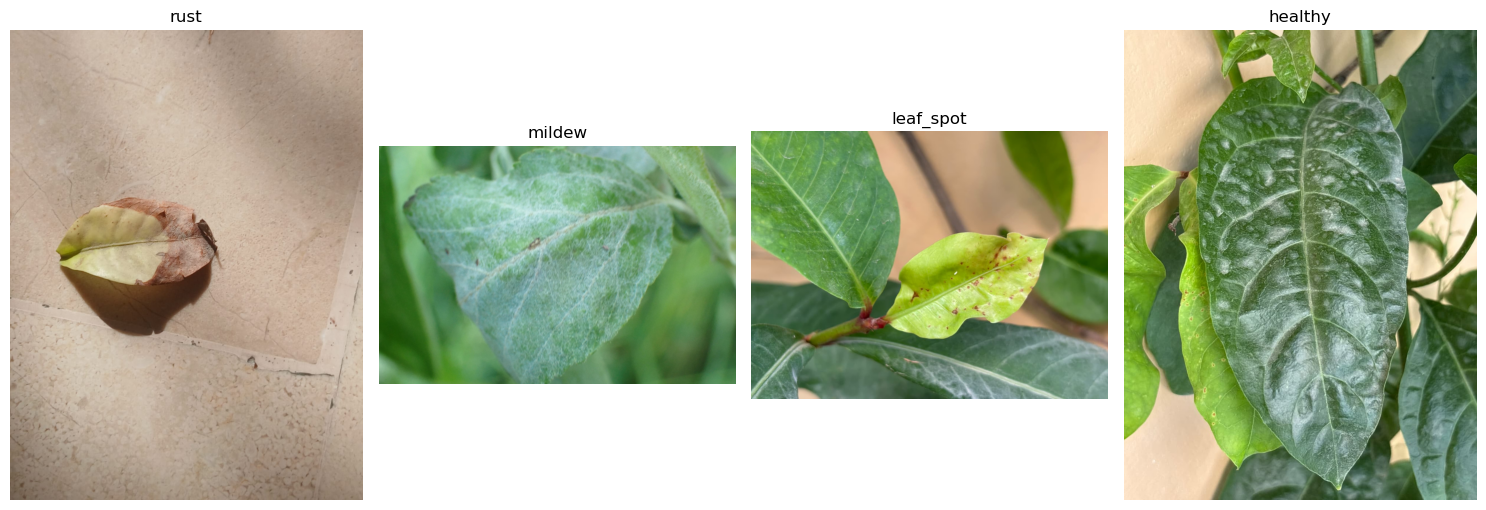

In [4]:
# Display one sample image from each class
unique_classes = list(set(labels))
plt.figure(figsize=(15, 5))

for i, disease in enumerate(unique_classes):
    # Find the first image that matches this disease
    sample_img_path = image_paths[labels.index(disease)]
    
    # Read and convert colors for matplotlib
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(unique_classes), i + 1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Set a standard image size for your future Neural Network
IMG_SIZE = 128 

processed_images = []
encoded_labels = []

# Create a dictionary to convert text labels to numbers (Label Encoding)
label_to_num = {disease: idx for idx, disease in enumerate(unique_classes)}
print(f"Label Encoding Map: {label_to_num}\n")

print("Starting Preprocessing Pipeline (Resizing & Normalizing)...")
for i, path in enumerate(image_paths):
    try:
        # 1. Read image
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 2. Resize image
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # 3. Normalize pixel values (scale 0-255 to 0.0-1.0)
        img_normalized = img_resized / 255.0
        
        processed_images.append(img_normalized)
        
        # 4. Encode label
        encoded_labels.append(label_to_num[labels[i]])
        
    except Exception as e:
        print(f"Error processing {path}: {e}")

# Convert lists to NumPy arrays for Machine Learning
X_data = np.array(processed_images)
y_data = np.array(encoded_labels)

print(f"Preprocessing Complete!")
print(f"X_data shape: {X_data.shape} -> (Samples, Height, Width, Channels)")
print(f"y_data shape: {y_data.shape} -> (Labels)")

Label Encoding Map: {'rust': 0, 'mildew': 1, 'leaf_spot': 2, 'healthy': 3}

Starting Preprocessing Pipeline (Resizing & Normalizing)...
Preprocessing Complete!
X_data shape: (594, 128, 128, 3) -> (Samples, Height, Width, Channels)
y_data shape: (594,) -> (Labels)
